# Create Music Group - Revenue & Streams Analysis
**Candidate:** Swapnil Dubey  
**Dataset:** Revenue and Streams data across 5 DSPs (Spotify, YouTube, Apple, Amazon, TikTok)  
**Objective:** Clean and merge revenue and streams data, flag incomplete months, compute Revenue Per Stream (RPS) baselines, and forecast revenue for months where DSP statements are missing or incomplete.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 2. Load Data

Two sheets from the source Excel file:
- **Revenue**: monthly gross revenue per DSP, country, and business unit
- **Streams**: monthly stream counts per DSP, country, and business unit

In [2]:
rev = pd.read_excel('data/Case_Study_Dataset__1_.xlsx', sheet_name='Revenue')
streams = pd.read_excel('data/Case_Study_Dataset__1_.xlsx', sheet_name='Streams')

print(f"Revenue: {rev.shape[0]:,} rows, {rev.shape[1]} columns")
print(f"Streams: {streams.shape[0]:,} rows, {streams.shape[1]} columns")

Revenue: 3,534 rows, 5 columns
Streams: 26,036 rows, 5 columns


## 3. Cleaning & Standardization

### 3.1 DSP Normalization

The revenue sheet contains ~25 DSP variants that map to 5 canonical platforms (as per in streams sheet). We consolidate them before merging.

In [3]:
dsp_map = {
    'Spotify': 'Spotify',
    'YouTube': 'YouTube',
    'YouTube Premium': 'YouTube',
    'YouTube - Ads': 'YouTube',
    'YouTube - Premium': 'YouTube',
    'YouTube Ad Revenue': 'YouTube',
    'YouTube - Audio Tier': 'YouTube',
    'YouTube Music': 'YouTube',
    'YouTube Music Family monthly': 'YouTube',
    'YouTube Music Individual monthly': 'YouTube',
    'YouTube Music Student monthly': 'YouTube',
    'YouTube Premium Family monthly': 'YouTube',
    'YouTube Premium Individual monthly': 'YouTube',
    'YouTube Premium Lite Individual monthly': 'YouTube',
    'YouTube Premium Student monthly': 'YouTube',
    'Youtube Licensing': 'YouTube',
    'YouTube - Other': 'YouTube',
    'Apple Inc.': 'Apple',
    'Apple Music': 'Apple',
    'Apple/iTunes': 'Apple',
    'Apple Music Dj Mixes': 'Apple',
    'Tiktok': 'TikTok',
    'Amazon': 'Amazon',
    'Amazon Prime': 'Amazon',
    'Amazon Unlimited': 'Amazon',
    'Amazon Ad Supported': 'Amazon',
    'Amazon Cloud': 'Amazon',
}

rev['dsp_clean'] = rev['dsp'].map(dsp_map)

unmapped = rev[rev['dsp_clean'].isna()]['dsp'].unique()
print("Unmapped DSPs:", unmapped if len(unmapped) > 0 else "None")

Unmapped DSPs: None


### 3.2 Column Renaming & Date Normalization

In [4]:
# Align column names between tables
rev = rev.rename(columns={'territory_name': 'country'})

# Normalize dates to monthly periods
rev['month'] = pd.to_datetime(rev['month']).dt.to_period('M')
streams['month'] = pd.to_datetime(streams['month']).dt.to_period('M')

### 3.3 Null Handling - Revenue

Checking for missing `total_gross_amount` values before merging.

In [5]:
print("Revenue nulls:")
print(rev.isnull().sum())

null_rows = rev[rev['total_gross_amount'].isna()]
print(f"\n{len(null_rows)} null revenue rows - breakdown by DSP and BU:")
print(null_rows.groupby(['dsp_clean', 'business_unit']).size())

Revenue nulls:
month                 0
business_unit         0
dsp                   0
country               0
total_gross_amount    9
dsp_clean             0
dtype: int64

9 null revenue rows - breakdown by DSP and BU:
dsp_clean  business_unit
Apple      BU 3             9
dtype: int64


In [6]:
# All 9 nulls are Apple Music / BU 3, spread across different countries and months.
# No systematic pattern — these are likely missing payout statements, not a data loading error.
# Not filling with 0 here — letting nulls propagate through the pipeline so they get
# estimated using the same RPS-based logic as the Forecast rows, ensuring consistency.
# Filling with 0 would silently understate Apple BU 3 revenue in otherwise Actual months.
#rev['total_gross_amount'] = rev['total_gross_amount'].fillna(0)

### 3.4 Country Alignment

The streams table contains more granular country breakdowns than the revenue table.
Countries present in streams but absent from revenue are bucketed as "All Other Locations" 
to enable a clean join without losing stream volume.

In [7]:
rev_countries = set(rev['country'].unique())
str_countries = set(streams['country'].unique())

extra_in_streams = str_countries - rev_countries
print(f"{len(extra_in_streams)} countries in Streams not in Revenue - bucketed to 'All Other Locations'")

streams['country'] = streams['country'].apply(
    lambda x: x if x in rev_countries else 'All Other Locations'
)

240 countries in Streams not in Revenue - bucketed to 'All Other Locations'


## 4. Aggregation & Merge

Group both tables to the same granularity: `month × DSP × business_unit × country`, 
then left-join streams to revenue.

In [8]:
streams_grouped = streams.groupby(
    ['month', 'dsp', 'business_unit', 'country']
)['total_streams'].sum().reset_index()

rev_grouped = rev.groupby(
    ['month', 'dsp_clean', 'business_unit', 'country']
)['total_gross_amount'].sum().reset_index()

merged = streams_grouped.merge(
    rev_grouped,
    how='left',
    left_on=['month', 'dsp', 'business_unit', 'country'],
    right_on=['month', 'dsp_clean', 'business_unit', 'country']
).drop(columns='dsp_clean')

print(f"Merged shape: {merged.shape}")
print(f"Null revenue rows after merge: {merged['total_gross_amount'].isna().sum()}")

Merged shape: (2000, 6)
Null revenue rows after merge: 188


## 5. Flagging Incomplete Months

Not all DSPs submit complete revenue statements every month. We need to distinguish 
months where revenue data is reliable ("Actual") from months where it's missing or 
suspiciously low ("Forecast").

**Methodology:** For each DSP, we compute average monthly revenue over Jan-Aug 2025, 
on the assumption that older months are more likely to have received complete statements 
given DSP payout delays of 1-2 months. Any DSP-month where total revenue falls below 
20% of that average is flagged as "Forecast" - this catches both outright nulls and 
partial submissions where only some statements have arrived.

**Limitation:** This baseline is not confirmed complete - if any Jan–Aug months contain 
partial submissions that still exceed the 20% threshold, they would inflate the baseline 
average and reduce the sensitivity of the flag. The cutoff at Aug 2025 was chosen 
pragmatically as the boundary before the most recent months where incomplete reporting 
is most likely.

In [9]:
# Compute per-DSP monthly totals
dsp_month_totals = merged.groupby(['month', 'dsp'])['total_gross_amount'].sum().reset_index()
dsp_month_totals.columns = ['month', 'dsp', 'monthly_total']

# Average monthly revenue per DSP (using data up to Aug 2025 as baseline)
baseline_period = dsp_month_totals[dsp_month_totals['month'].astype(str) <= '2025-08']
dsp_avg = baseline_period.groupby('dsp')['monthly_total'].mean().reset_index()
dsp_avg.columns = ['dsp', 'avg_monthly_revenue']
dsp_avg['threshold'] = dsp_avg['avg_monthly_revenue'] * 0.20

# Merge threshold and flag
dsp_month_totals = dsp_month_totals.merge(dsp_avg[['dsp', 'threshold']], on='dsp', how='left')
dsp_month_totals['flag'] = dsp_month_totals.apply(
    lambda row: 'Forecast' if (pd.isna(row['monthly_total']) or row['monthly_total'] < row['threshold']) else 'Actual',
    axis=1
)

print(dsp_month_totals.groupby(['dsp', 'flag']).size().unstack(fill_value=0))

flag     Actual  Forecast
dsp                      
Amazon        8         2
Apple         9         1
Spotify       8         2
TikTok        9         1
YouTube       9         1


In [10]:
# Propagate flags to the row-level merged table
merged = merged.merge(dsp_month_totals[['month', 'dsp', 'flag']], on=['month', 'dsp'], how='left')
print("Flag distribution:")
print(merged['flag'].value_counts())

Flag distribution:
flag
Actual      1720
Forecast     280
Name: count, dtype: int64


## 6. RPS Baseline & Visualization

Revenue Per Stream (RPS) = total revenue / total streams × 1,000,000 (per million streams).

We compute RPS only on "Actual" months to establish a reliable baseline per DSP.
YouTube's RPS is more volatile, so we use a longer lookback window (Apr-Aug 2025) vs. Jun-Aug 2025 for other DSPs. (Need more data to average out the noise.)

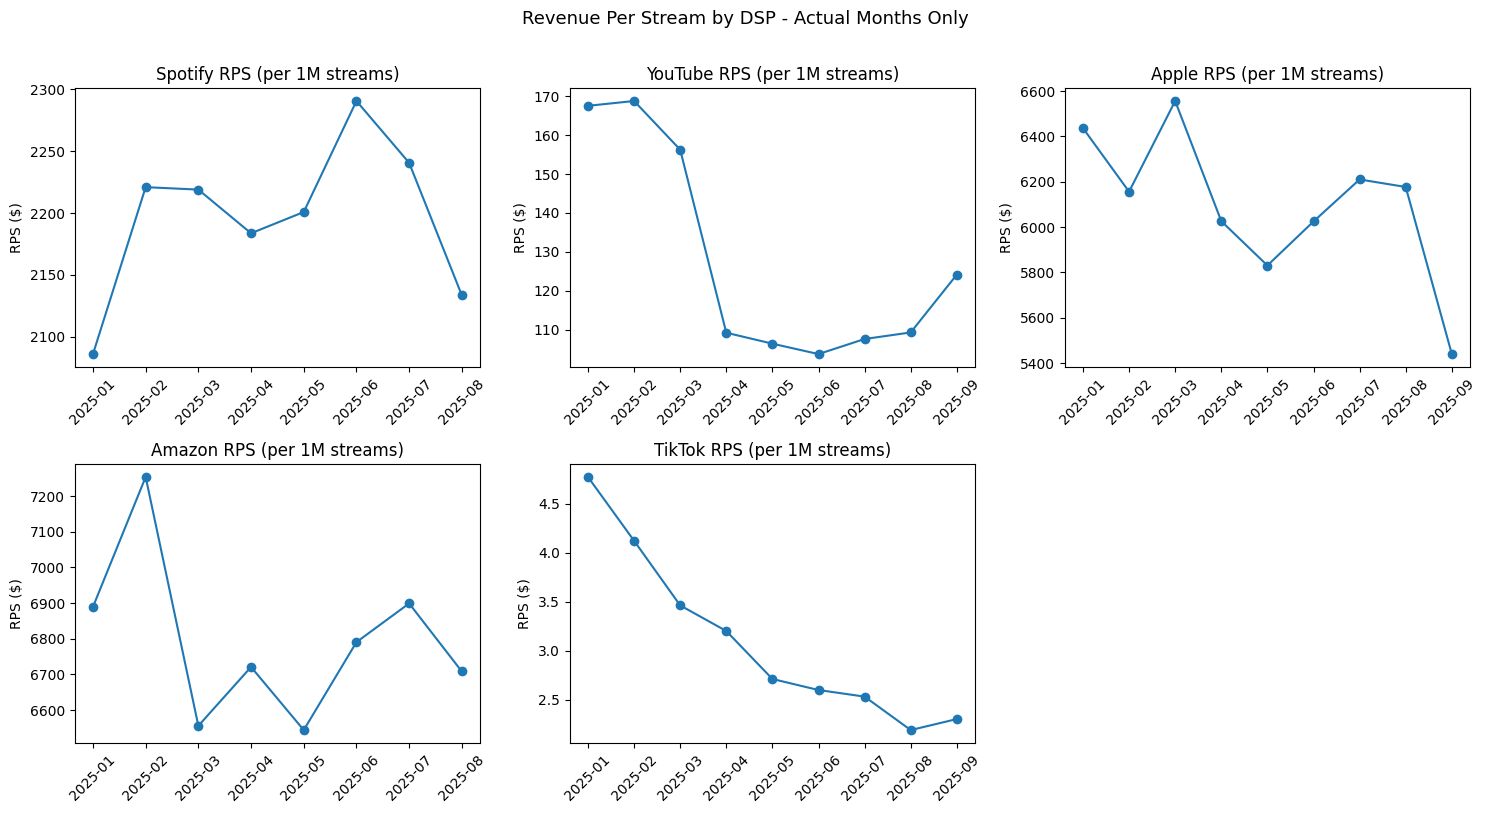

In [11]:
# Add stream totals to DSP-month table
streams_by_dsp_month = streams_grouped.groupby(['month', 'dsp'])['total_streams'].sum().reset_index()
dsp_month_totals = dsp_month_totals.merge(streams_by_dsp_month, on=['month', 'dsp'])
dsp_month_totals['RPS'] = dsp_month_totals['monthly_total'] / dsp_month_totals['total_streams'] * 1_000_000

# Plot RPS trends for Actual months only
complete = dsp_month_totals[dsp_month_totals['flag'] == 'Actual']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, dsp in enumerate(['Spotify', 'YouTube', 'Apple', 'Amazon', 'TikTok']):
    df = complete[complete['dsp'] == dsp].sort_values('month')
    axes[i].plot(df['month'].astype(str), df['RPS'], marker='o')
    axes[i].set_title(f'{dsp} RPS (per 1M streams)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('RPS ($)')

axes[5].set_visible(False)
plt.suptitle('Revenue Per Stream by DSP - Actual Months Only', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('output/rps_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Coefficient of Variation - how stable is each DSP's RPS?
print("RPS Coefficient of Variation (lower = more stable):")
for dsp in ['Spotify', 'YouTube', 'Apple', 'Amazon', 'TikTok']:
    df = complete[complete['dsp'] == dsp]['RPS']
    cov = df.std() / df.mean()
    print(f"  {dsp}: {cov:.3f}")

RPS Coefficient of Variation (lower = more stable):
  Spotify: 0.029
  YouTube: 0.217
  Apple: 0.054
  Amazon: 0.034
  TikTok: 0.283


## 7. Forecasting Missing Revenue

For months flagged as "Forecast", we estimate revenue using:

`Forecasted Revenue = RPS Baseline × Streams / 1,000,000`

**Baseline windows:**
- All DSPs except YouTube: 3-month average (Jun-Aug 2025) - stable, recent
- YouTube: 5-month average (Apr-Aug 2025) - More volatile so using more data (in a relatively stable range of months zone)

In [13]:
# Compute RPS baseline per DSP
non_yt = dsp_month_totals[
    (dsp_month_totals['dsp'] != 'YouTube') &
    (dsp_month_totals['month'].astype(str) >= '2025-06') &
    (dsp_month_totals['month'].astype(str) <= '2025-08') &
    (dsp_month_totals['flag'] == 'Actual')
]

yt = dsp_month_totals[
    (dsp_month_totals['dsp'] == 'YouTube') &
    (dsp_month_totals['month'].astype(str) >= '2025-04') &
    (dsp_month_totals['month'].astype(str) <= '2025-08') &
    (dsp_month_totals['flag'] == 'Actual')
]

non_yt_rps = non_yt.groupby('dsp')['RPS'].mean().reset_index()
yt_rps = pd.DataFrame({'dsp': ['YouTube'], 'RPS': [yt['RPS'].mean()]})

rps_baseline = pd.concat([non_yt_rps, yt_rps], ignore_index=True)
rps_baseline.columns = ['dsp', 'rps_baseline']

print("RPS Baselines used for forecasting:")
print(rps_baseline.to_string(index=False))

RPS Baselines used for forecasting:
    dsp  rps_baseline
 Amazon   6799.238959
  Apple   6137.247333
Spotify   2221.663720
 TikTok      2.440821
YouTube    107.307603


In [14]:
# Apply forecasts to merged table
merged = merged.merge(rps_baseline[['dsp', 'rps_baseline']], on='dsp', how='left')
merged['forecasted'] = merged['rps_baseline'] * merged['total_streams'] / 1_000_000

merged['total_gross_amount'] = merged.apply(
    lambda row: row['forecasted'] if row['flag'] == 'Forecast' or pd.isna(row['total_gross_amount']) else row['total_gross_amount'],
    axis=1
)

merged['RPS'] = merged['total_gross_amount'] / merged['total_streams'] * 1_000_000
merged = merged.drop(columns=['forecasted', 'rps_baseline'])

print(f"Nulls remaining in total_gross_amount: {merged['total_gross_amount'].isna().sum()}")
print(f"\nFinal dataset shape: {merged.shape}")
merged.head()

Nulls remaining in total_gross_amount: 0

Final dataset shape: (2000, 8)


,month,dsp,business_unit,country,total_streams,total_gross_amount,flag,RPS
0,2025-01,Amazon,BU 1,All Other Locations,526881,3431.0,Actual,6511.906863
1,2025-01,Amazon,BU 1,Australia,32830,219.0,Actual,6670.727993
2,2025-01,Amazon,BU 1,Brazil,77591,245.0,Actual,3157.582709
3,2025-01,Amazon,BU 1,Canada,79619,1878.0,Actual,23587.334681
4,2025-01,Amazon,BU 1,France,115564,765.0,Actual,6619.708560


## 8. Export

In [15]:
merged['month'] = merged['month'].astype(str)
merged.to_excel('output/cmg_finance_output.xlsx', index=False)
print("Exported to output/cmg_finance_output.xlsx")

Exported to output/cmg_finance_output.xlsx


## 9. Bonus: Interesting Findings

In [16]:
print(merged.groupby('flag')[['total_gross_amount', 'RPS']].describe())


         total_gross_amount                                         \
                      count          mean            std       min   
flag                                                                 
Actual               1720.0  58347.257558  176896.075744  0.000000   
Forecast              280.0  63954.609871  147328.506689  4.151996   

                                                                    RPS  \
                  25%           50%           75%           max   count   
flag                                                                      
Actual    1578.000000   8932.500000  36619.750000  2.226002e+06  1720.0   
Forecast  3223.864252  12033.284175  41952.120285  1.035669e+06   280.0   

                                                                      \
                 mean          std       min         25%         50%   
flag                                                                   
Actual    3044.607256  4213.774330  0.000000   51.855555 

In [17]:
# Total revenue by DSP
print(merged.groupby('dsp')['total_gross_amount'].sum().sort_values(ascending=False))

# Total streams by DSP  
print(merged.groupby('dsp')['total_streams'].sum().sort_values(ascending=False))

# Revenue by BU
print(merged.groupby('business_unit')['total_gross_amount'].sum().sort_values(ascending=False))

dsp
Spotify    4.857536e+07
YouTube    4.788202e+07
Apple      1.573968e+07
TikTok     3.362622e+06
Amazon     2.704891e+06
Name: total_gross_amount, dtype: float64
dsp
TikTok     1148578554178
YouTube     397786051177
Spotify      22054517696
Apple         2582992482
Amazon         398620438
Name: total_streams, dtype: int64
business_unit
BU 1    4.519262e+07
BU 2    3.631023e+07
BU 4    2.450606e+07
BU 3    1.225566e+07
Name: total_gross_amount, dtype: float64


In [18]:
# Monthly revenue trend (are we growing?)
print(merged.groupby('month')['total_gross_amount'].sum().sort_index())

# Top territories by revenue
print(merged.groupby('country')['total_gross_amount'].sum().sort_values(ascending=False))

month
2025-01    1.047660e+07
2025-02    1.043622e+07
2025-03    1.165160e+07
2025-04    1.178424e+07
2025-05    1.191085e+07
2025-06    1.202309e+07
2025-07    1.277412e+07
2025-08    1.226091e+07
2025-09    1.265120e+07
2025-10    1.229576e+07
Name: total_gross_amount, dtype: float64
country
United States of America    6.065222e+07
All Other Locations         2.770746e+07
United Kingdom              7.289811e+06
Germany                     5.865821e+06
Canada                      3.857053e+06
France                      3.023452e+06
Brazil                      2.795291e+06
Australia                   2.601769e+06
Mexico                      2.490373e+06
India                       1.981319e+06
Name: total_gross_amount, dtype: float64


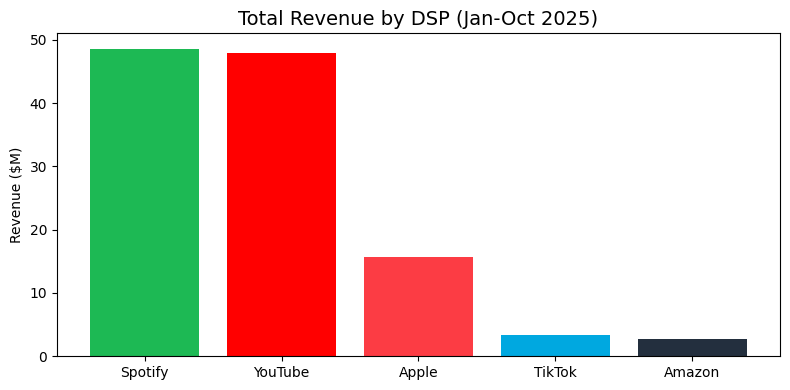

In [19]:
import matplotlib.pyplot as plt

dsp_rev = merged.groupby('dsp')['total_gross_amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dsp_rev.index, dsp_rev.values / 1e6, color=['#1DB954','#FF0000','#FC3C44','#00A8E0','#232F3E'])
ax.set_title('Total Revenue by DSP (Jan-Oct 2025)', fontsize=14)
ax.set_ylabel('Revenue ($M)')
plt.tight_layout()
plt.savefig('output/revenue_by_dsp.png', dpi=150)
plt.show()

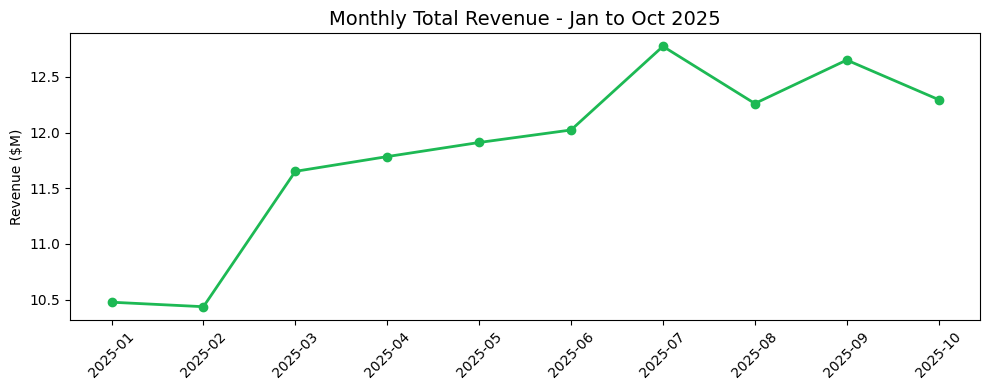

In [20]:
monthly = merged.groupby('month')['total_gross_amount'].sum()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index.astype(str), monthly.values / 1e6, marker='o', color='#1DB954', linewidth=2)
ax.set_title('Monthly Total Revenue - Jan to Oct 2025', fontsize=14)
ax.set_ylabel('Revenue ($M)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('output/monthly_revenue_trend.png', dpi=150)
plt.show()

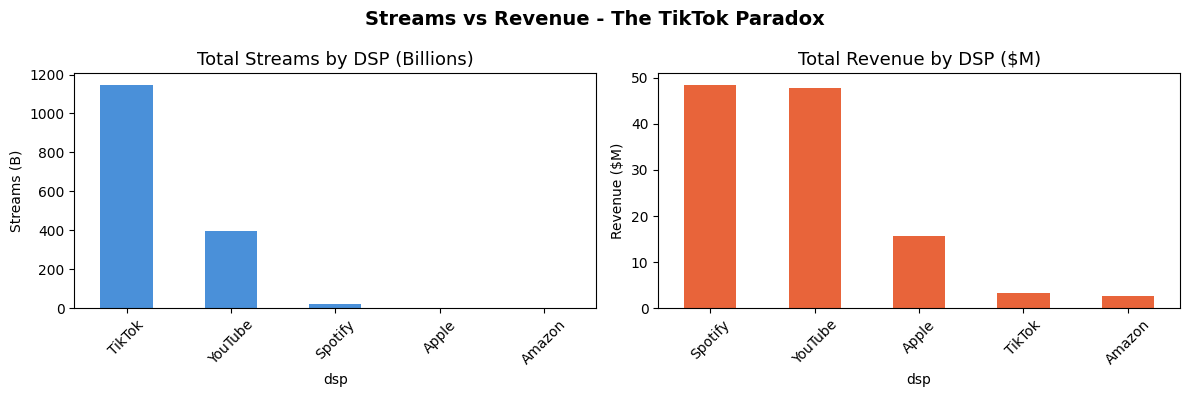

In [21]:
dsp_streams = merged.groupby('dsp')['total_streams'].sum() / 1e9
dsp_rev2 = merged.groupby('dsp')['total_gross_amount'].sum() / 1e6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
dsp_streams.sort_values(ascending=False).plot.bar(ax=ax1, color='#4A90D9')
ax1.set_title('Total Streams by DSP (Billions)', fontsize=13)
ax1.set_ylabel('Streams (B)')
ax1.tick_params(axis='x', rotation=45)

dsp_rev2.sort_values(ascending=False).plot.bar(ax=ax2, color='#E8643A')
ax2.set_title('Total Revenue by DSP ($M)', fontsize=13)
ax2.set_ylabel('Revenue ($M)')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Streams vs Revenue - The TikTok Paradox', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/tiktok_paradox.png', dpi=150)
plt.show()

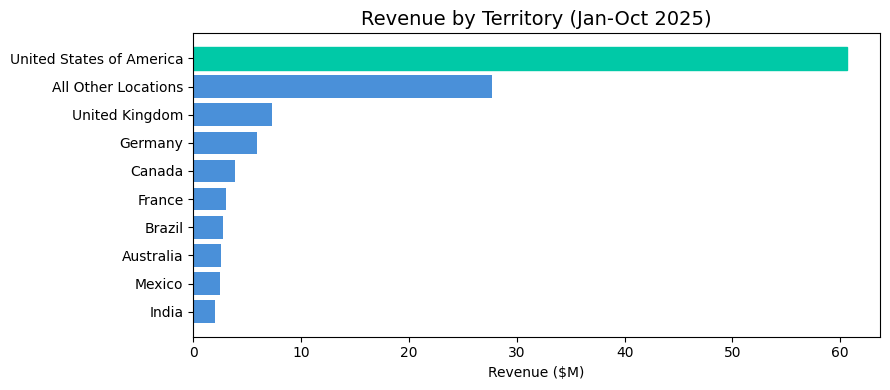

In [22]:
country_rev = merged.groupby('country')['total_gross_amount'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(country_rev.index, country_rev.values / 1e6, color='#4A90D9')
bars[-1].set_color('#00C9A7')  # highlight US
ax.set_title('Revenue by Territory (Jan-Oct 2025)', fontsize=14)
ax.set_xlabel('Revenue ($M)')
plt.tight_layout()
plt.savefig('output/revenue_by_territory.png', dpi=150)
plt.show()